In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
z = 9.5
v = 0
d = 1e-3
rho_p = 7800
rho_f = 920
mu = 0.081
dt = 0.01
g = 10

f1 = mu/(rho_f*d)
f2 = (rho_p - rho_f) * d**2 * g / (18*mu)
print(f1)
print(f2)
# d = np.cbrt(18*mu**2/(rho_f*(rho_p - rho_f)*g))
# print(d)


0.08804347826086957
0.04718792866941015


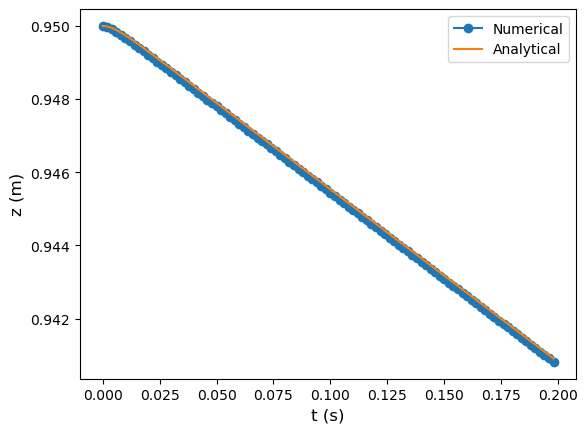

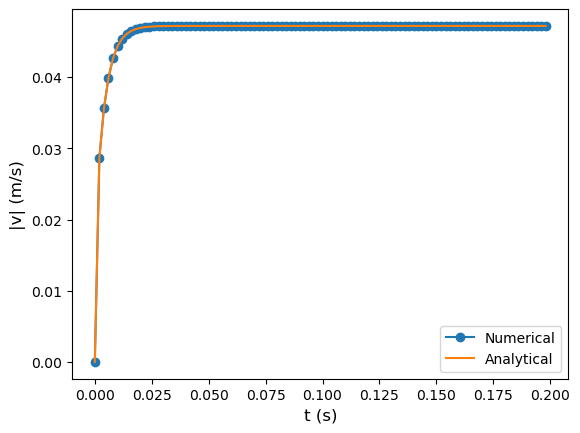

In [6]:
z0 = 0.95
v0 = 0
d = 1e-3
rho_p = 7800
rho_f = 920
mu = 0.081
g = -10
A = 18*mu/(rho_p*d**2)
B = (1-rho_f/rho_p)*g
#20138
t = np.linspace(0, 20.136, 10069)
z = z0 + B/A**2 * (A*t + np.exp(-A*t) - 1)
v = B/A*(1-np.exp(-A*t))
csv_data = np.loadtxt('../output_files/stokes_positions.csv', delimiter=',')
z_num = csv_data[:,3]
v_num = csv_data[:,6]
plt.plot(t[:100],z_num[:100], label = 'Numerical', marker = 'o')
plt.plot(t[:100],z[:100], label = 'Analytical')
plt.xlabel('t (s)', fontsize=12)
plt.ylabel('z (m)', fontsize=12)
plt.legend()
#plt.savefig('stokes_position.png', dpi=400, bbox_inches='tight')
plt.show()

plt.plot(t[:100],-v_num[:100], label = 'Numerical', marker = 'o')
plt.plot(t[:100],-v_num[:100], label = 'Analytical')
#plt.xscale('log')
plt.xlabel('t (s)', fontsize=12)
plt.ylabel('|v| (m/s)', fontsize=12)
plt.legend()
#plt.savefig('stokes_velocity.png', dpi=400, bbox_inches='tight')
plt.show()

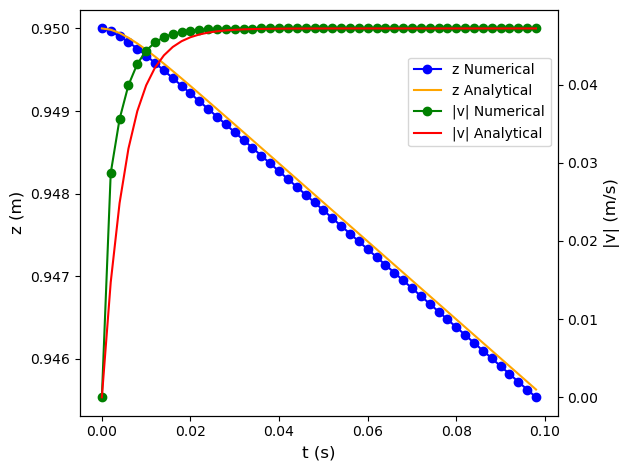

In [13]:
# Sample data
size = 50
x = t[:size]
y1 = z[:size] 
y1_num = z_num[:size]             # First y data
y2 = -v[:size]
y2_num = -v_num[:size]

         # Second y data

fig, ax1 = plt.subplots()

# Plot on the first y-axis
ax1.plot(x, y1_num, 'blue', label='z Numerical', marker = 'o')
ax1.plot(x, y1, 'orange', label='z Analytical')
ax1.set_xlabel('t (s)', fontsize = 12)
ax1.set_ylabel('z (m)', color='black', fontsize = 12)
ax1.tick_params(axis='y', labelcolor='black')

# Create a second y-axis sharing the same x-axis
ax2 = ax1.twinx()
ax2.plot(x, y2_num, 'green', label='|v| Numerical', marker = 'o')
ax2.plot(x, y2, 'red', label='|v| Analytical')
ax2.set_ylabel('|v| (m/s)', color='black', fontsize = 12)
ax2.tick_params(axis='y', labelcolor='black')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

# Plot legend manually in figure coordinates
ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc='upper right',              # general area
    bbox_to_anchor=(1.0, 0.9),    # (x, y) in axes fraction
    fontsize=10,
    frameon=True
)

# Optional: save
plt.tight_layout()
plt.savefig('stokes.png', dpi=400)
plt.show()